## Part 2

In [375]:
#Import needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

#Sklearn imports, used for ML models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.neighbors import LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [376]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "uciml/red-wine-quality-cortez-et-al-2009"
)

df = pd.read_csv(f"{path}/winequality-red.csv")

#Preview the dataset and info about the columns and data types
print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [377]:
#Train/test/eval splits
train_reduced, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_reduced, test_size=0.15, random_state=42)

print(f"Total samples:         {len(df)}")
print(f"Holdout test set:      {len(test_df)} ({len(test_df)/len(df):.0%})")
print(f"train_reduced:         {len(train_reduced)} ({len(train_reduced)/len(df):.0%})")
print(f"  Train:               {len(train_df)} ({len(train_df)/len(df):.0%})")
print(f"  Validation:          {len(val_df)} ({len(val_df)/len(df):.0%})")

Total samples:         1599
Holdout test set:      240 (15%)
train_reduced:         1359 (85%)
  Train:               1155 (72%)
  Validation:          204 (13%)


In [378]:
#Data cleaning

#1. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

#2. Check for duplicates
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

#3. Out of Range Values
#Check for negative values in features that should be non-negative
non_negative_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                            'pH', 'sulphates', 'alcohol']
for feature in non_negative_features:
    num_negative = (df[feature] < 0).sum()
    if num_negative > 0:
        print(f"\nFeature '{feature}' has {num_negative} negative values.")
else:
    print("\nNo negative values found in non-negative features.")



Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Number of duplicate rows: 240

No negative values found in non-negative features.


In [379]:
#Clean duplicate rows
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {num_duplicates} duplicate rows. New total: {len(df)}")

Removed 240 duplicate rows. New total: 1359


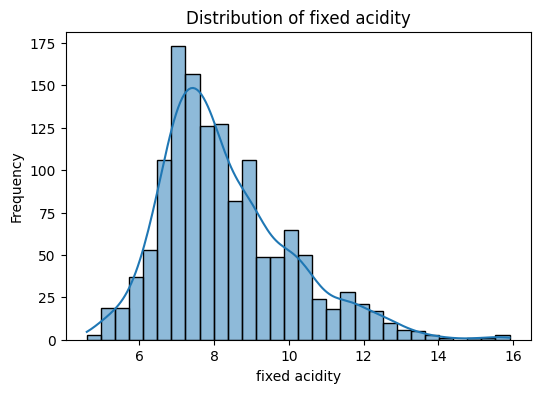

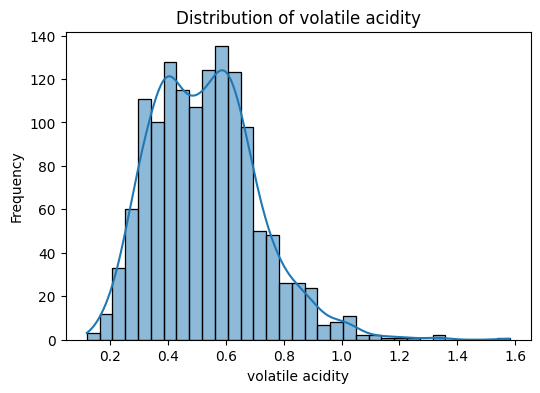

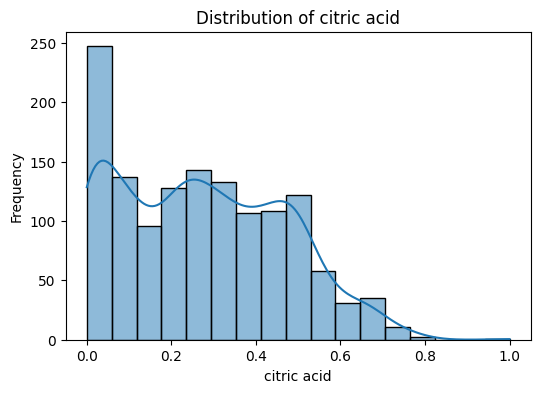

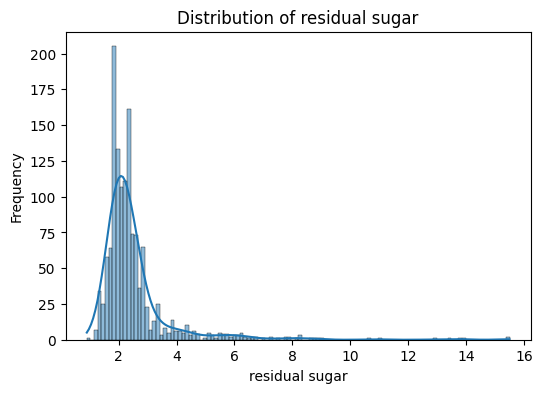

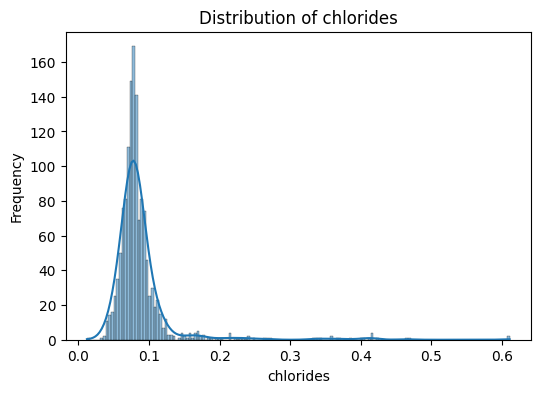

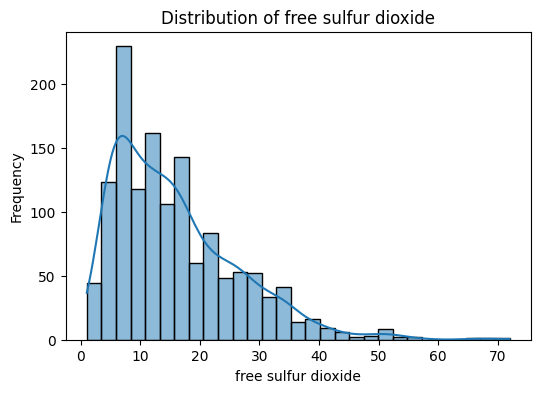

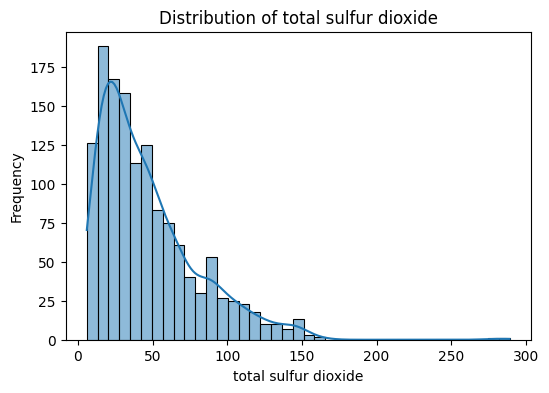

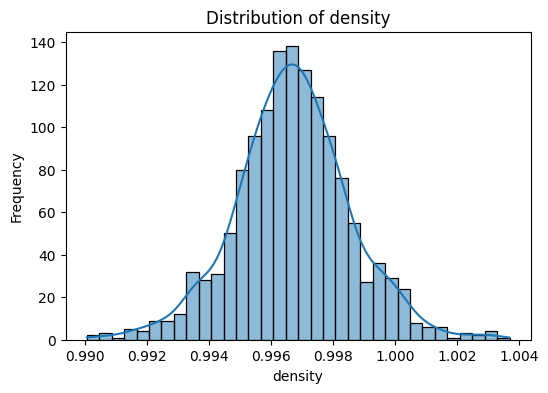

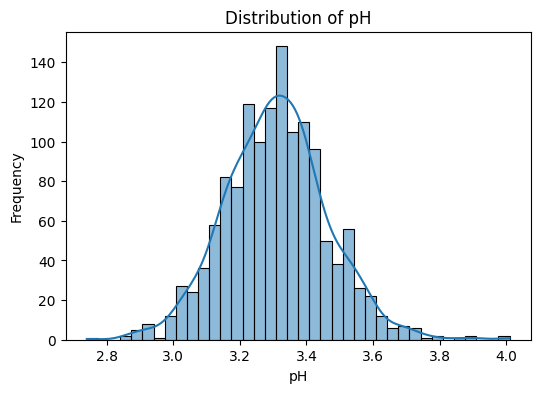

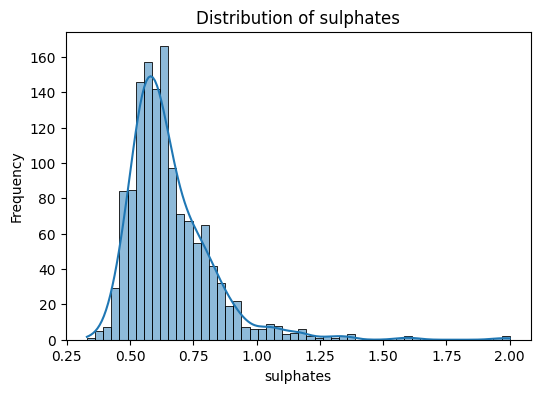

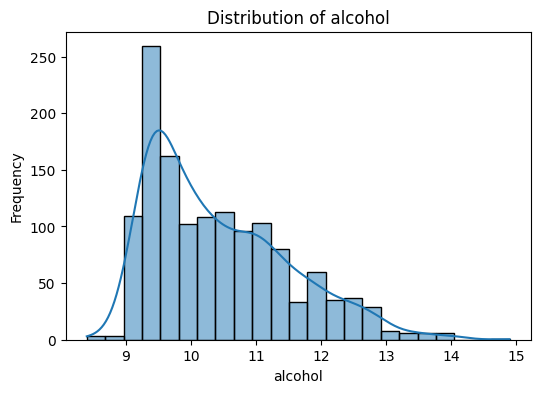

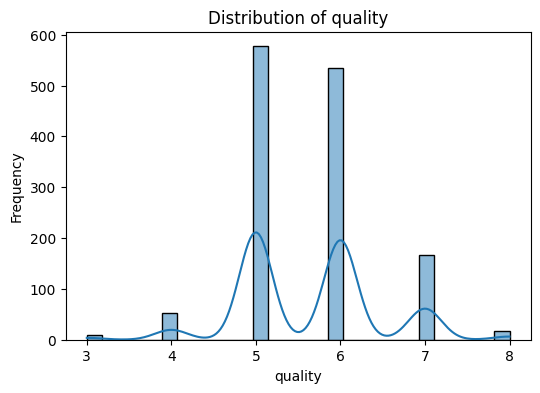

In [380]:
#Visualize distribution of all features
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()



/Users/jonathanc/dev/school/Data_Science/DataScienceA2/.venv/lib/python3.9/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


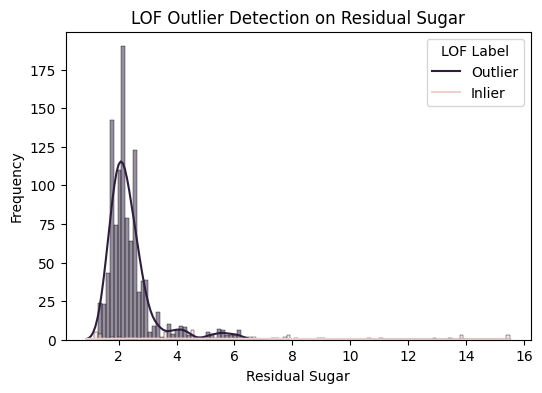

In [381]:
#Perform LOF to detect outliers in residual sugar

#First calculate mean for imputation
train_df_imputed = train_df.copy()
mean_residual_sugar = train_df_imputed['residual sugar'].mean()

#Perform LOF on residual sugar
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
train_df_imputed['lof_residual_sugar'] = lof.fit_predict(train_df_imputed[['residual sugar']].fillna(mean_residual_sugar))

#Visualize LOF results
plt.figure(figsize=(6, 4))
sns.histplot(data=train_df_imputed, x='residual sugar', kde=True, hue='lof_residual_sugar')
plt.title("LOF Outlier Detection on Residual Sugar")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.legend(title='LOF Label', labels=['Outlier', 'Inlier'])
plt.show()

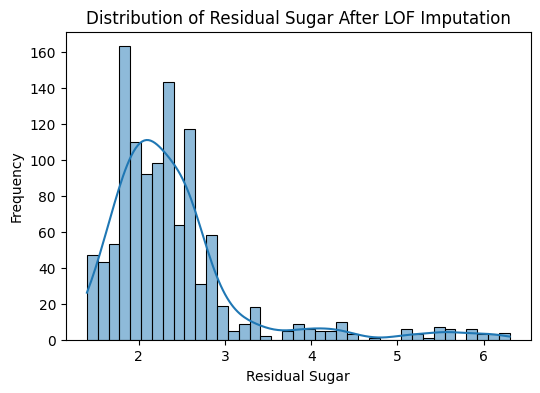

In [382]:
#Copy dataset and impute outliers with mean value
train_df_imputed.loc[train_df_imputed['lof_residual_sugar'] == -1, 'residual sugar'] = mean_residual_sugar

#Re-visualize distribution of residual sugar after imputation
plt.figure(figsize=(6, 4))
sns.histplot(train_df_imputed['residual sugar'], kde=True)
plt.title("Distribution of Residual Sugar After LOF Imputation")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()

In [383]:
#Dataset with 2 aggregate features
#Total acidity = fixed acidity + volatile acidity, Chemical Balance = citric acid / (fixed acidity + volatile acidity)
train_df_imputed['total acidity'] = train_df_imputed['fixed acidity'] + train_df_imputed['volatile acidity']
train_df_imputed['chemical balance'] = train_df_imputed['citric acid'] / (train_df_imputed['fixed acidity'] + train_df_imputed['volatile acidity'])

In [384]:
#Cleaned dataset with binary quality binning: Poor=0 (1-5), Good=1 (6-10)
train_df_binned = train_df_imputed.copy()

def quality_bin(quality):
    if quality <= 5:
        return 0  # Poor
    else:
        return 1  # Good

train_df_binned['quality_bin'] = train_df_binned['quality'].apply(quality_bin)

In [385]:
#Apply same pipeline to val_df (using stats from train only)
val_df_imputed = val_df.copy()

#Apply same aggregate features
val_df_imputed['total acidity'] = val_df_imputed['fixed acidity'] + val_df_imputed['volatile acidity']
val_df_imputed['chemical balance'] = val_df_imputed['citric acid'] / (val_df_imputed['fixed acidity'] + val_df_imputed['volatile acidity'])

#Apply same ordinal quality binning (0=Low, 1=Medium, 2=High)
val_df_binned = val_df_imputed.copy()
val_df_binned['quality_bin'] = val_df_binned['quality'].apply(quality_bin)

## Experiment 2.1: Baseline Decision Tree on original dataset

Experiment 1
4-Fold CV F1 (macro): 0.258

Decision Tree Classifier on Uncleaned, un-imputed dataset
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.13      0.29      0.18         7
           5       0.53      0.87      0.66        77
           6       0.44      0.04      0.08        91
           7       0.24      0.45      0.32        22
           8       0.20      0.33      0.25         6

    accuracy                           0.42       204
   macro avg       0.26      0.33      0.25       204
weighted avg       0.44      0.42      0.33       204



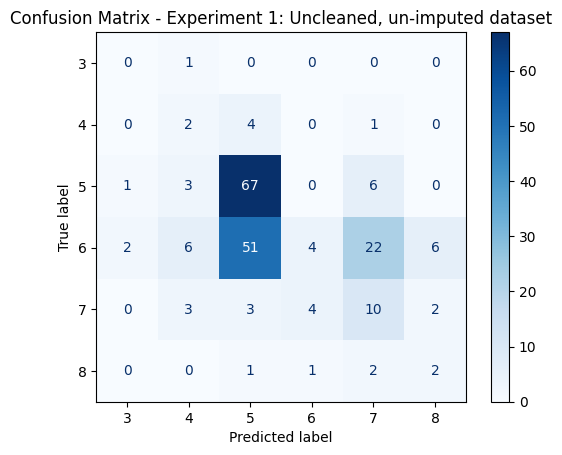

In [386]:
#Experiment 1: Decision Tree Classifier on Uncleaned, un-imputed dataset
from sklearn.model_selection import cross_val_score, StratifiedKFold

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

#4-fold stratified CV on train_reduced
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_scores_1 = cross_val_score(dt, train_reduced.drop(columns=['quality']), train_reduced['quality'],
                               cv=cv, scoring='f1_macro')
print(f"Experiment 1")
print(f"4-Fold CV F1 (macro): {cv_scores_1.mean():.3f}")

#Train on train_df, evaluate on val_df
dt.fit(train_df.drop(columns=['quality']), train_df['quality'])
val_preds_dt = dt.predict(val_df.drop(columns=['quality']))

print("\nDecision Tree Classifier on Uncleaned, un-imputed dataset")
print(classification_report(val_df['quality'], val_preds_dt))

cm = confusion_matrix(val_df['quality'], val_preds_dt, labels=dt.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Experiment 1: Uncleaned, un-imputed dataset")
plt.show()

## Experiment 2.2: Tweaked Decision Tree parameters on cleaned dataset

Experiment 2
4-Fold CV F1 (macro): 0.288

Decision Tree Classifier on cleaned, imputed and aggregate feature dataset
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.17      0.57      0.26         7
           5       0.67      0.73      0.70        77
           6       0.59      0.30      0.39        91
           7       0.30      0.55      0.39        22
           8       0.33      0.17      0.22         6

    accuracy                           0.49       204
   macro avg       0.34      0.38      0.33       204
weighted avg       0.56      0.49      0.50       204



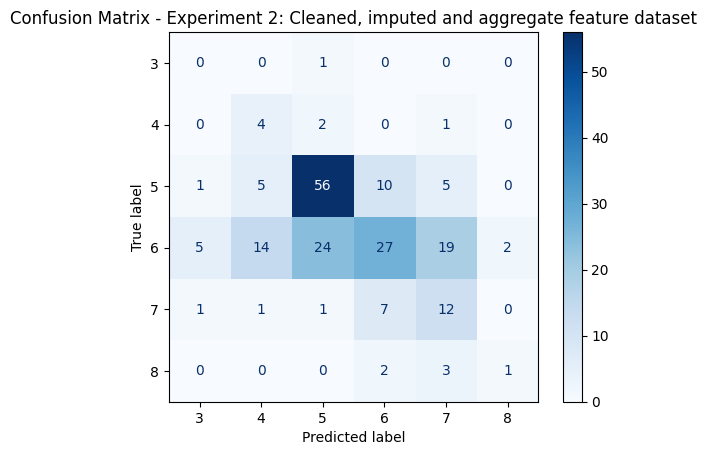

In [387]:
#Experiment 2: Decision Tree Classifier on cleaned, imputed and aggregate feature dataset
dt_cleaned = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

drop_cols = ['quality', 'lof_residual_sugar']
train_features = train_df_imputed.drop(columns=drop_cols)
val_features = val_df_imputed.drop(columns=['quality'])

#Build train_reduced_imputed for CV
train_reduced_imputed = train_reduced.copy()
train_reduced_imputed['total acidity'] = train_reduced_imputed['fixed acidity'] + train_reduced_imputed['volatile acidity']
train_reduced_imputed['chemical balance'] = train_reduced_imputed['citric acid'] / (train_reduced_imputed['fixed acidity'] + train_reduced_imputed['volatile acidity'])

#4-fold stratified CV on train_reduced_imputed
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_scores_2 = cross_val_score(dt_cleaned, train_reduced_imputed.drop(columns=['quality']),
                               train_reduced_imputed['quality'], cv=cv, scoring='f1_macro')
print(f"Experiment 2")
print(f"4-Fold CV F1 (macro): {cv_scores_2.mean():.3f}")

#Train on train_df_imputed, evaluate on val_df_imputed
dt_cleaned.fit(train_features, train_df_imputed['quality'])
val_preds_dt_cleaned = dt_cleaned.predict(val_features)

print("\nDecision Tree Classifier on cleaned, imputed and aggregate feature dataset")
print(classification_report(val_df_imputed['quality'], val_preds_dt_cleaned))

cm_cleaned = confusion_matrix(val_df_imputed['quality'], val_preds_dt_cleaned, labels=dt_cleaned.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm_cleaned, display_labels=dt_cleaned.classes_).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Experiment 2: Cleaned, imputed and aggregate feature dataset")
plt.show()

## Experiment 2.3: Tweaked Decision Tree parameters on cleaned dataset with Good-Bad binning

Experiment 3
4-Fold CV F1 (macro): 0.723

Decision Tree — Binary Quality Binning (0=Poor, 1=Good)
              precision    recall  f1-score   support

        Poor       0.63      0.81      0.71        85
        Good       0.83      0.66      0.73       119

    accuracy                           0.72       204
   macro avg       0.73      0.73      0.72       204
weighted avg       0.75      0.72      0.72       204



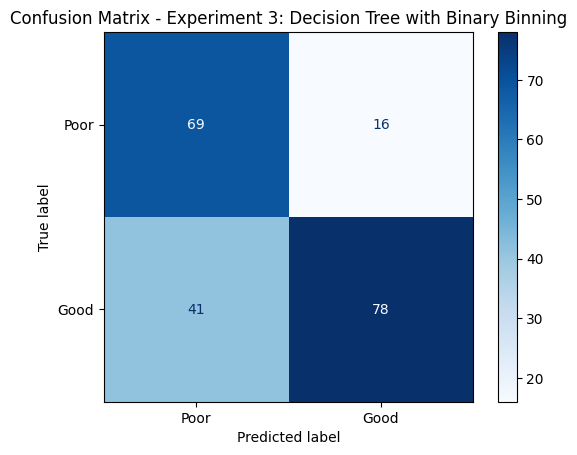

In [388]:
#Experiment 3: Decision Tree Classifier with binary quality binning (0=Poor, 1=Good)
dt_binned = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

feature_cols = [c for c in val_df_binned.columns if c not in ['quality', 'quality_bin']]

X3 = train_df_binned[feature_cols]
y3 = train_df_binned['quality_bin']

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_scores_3 = cross_val_score(dt_binned, X3, y3, cv=cv, scoring='f1_macro')
print(f"Experiment 3")
print(f"4-Fold CV F1 (macro): {cv_scores_3.mean():.3f}")

dt_binned.fit(train_df_binned[feature_cols], train_df_binned['quality_bin'])
val_preds_dt_binned = dt_binned.predict(val_df_binned[feature_cols])

print("\nDecision Tree — Binary Quality Binning (0=Poor, 1=Good)")
print(classification_report(val_df_binned['quality_bin'], val_preds_dt_binned, target_names=['Poor', 'Good']))

cm_binned = confusion_matrix(val_df_binned['quality_bin'], val_preds_dt_binned)
ConfusionMatrixDisplay(confusion_matrix=cm_binned, display_labels=['Poor', 'Good']).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Experiment 3: Decision Tree with Binary Binning")
plt.show()

## Experiment 4.1: Random Forest Classifier on cleaned dataset with Good-Bad binning

Experiment 4
4-Fold CV F1 (macro): 0.764

Random Forest — Binary Quality Binning (0=Poor, 1=Good)
              precision    recall  f1-score   support

        Poor       0.75      0.85      0.80        85
        Good       0.88      0.80      0.84       119

    accuracy                           0.82       204
   macro avg       0.81      0.82      0.82       204
weighted avg       0.83      0.82      0.82       204



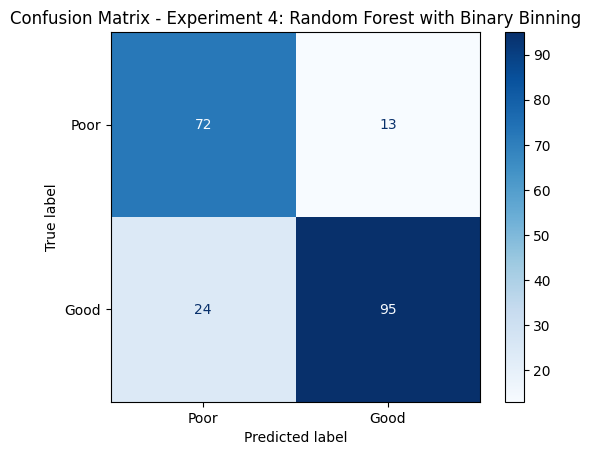

In [389]:
#Experiment 4: Random Forest Classifier with binary quality binning (0=Poor, 1=Good)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

feature_cols = [c for c in val_df_binned.columns if c not in ['quality', 'quality_bin']]

X_rf = train_df_binned[feature_cols]
y_rf = train_df_binned['quality_bin']

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf, X_rf, y_rf, cv=cv, scoring='f1_macro')
print(f"Experiment 4")
print(f"4-Fold CV F1 (macro): {cv_scores_rf.mean():.3f}")

rf.fit(train_df_binned[feature_cols], train_df_binned['quality_bin'])
val_preds_rf = rf.predict(val_df_binned[feature_cols])

print("\nRandom Forest — Binary Quality Binning (0=Poor, 1=Good)")
print(classification_report(val_df_binned['quality_bin'], val_preds_rf, target_names=['Poor', 'Good']))

cm_rf = confusion_matrix(val_df_binned['quality_bin'], val_preds_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Poor', 'Good']).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Experiment 4: Random Forest with Binary Binning")
plt.show()

## Final Evaluation: Retrain best model (Experiment 4 - Random Forest) on full train_reduced, evaluate on holdout test set

=== FINAL TEST SET EVALUATION ===
Test set size: 240 samples (never seen during training or tuning)

              precision    recall  f1-score   support

        Poor       0.74      0.78      0.76       108
        Good       0.81      0.78      0.80       132

    accuracy                           0.78       240
   macro avg       0.78      0.78      0.78       240
weighted avg       0.78      0.78      0.78       240

Test F1 (macro): 0.778


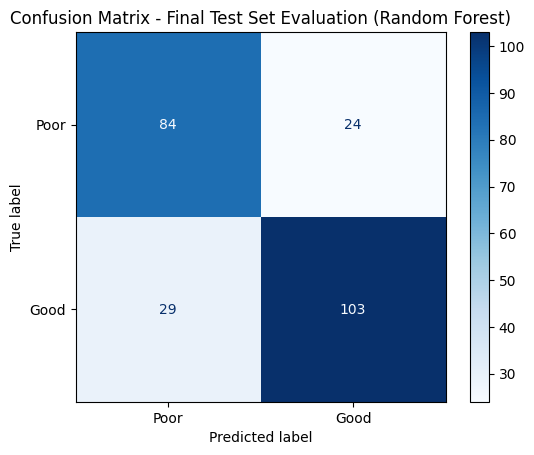

In [390]:
#Apply same preprocessing to test_df
test_df_final = test_df.copy()
test_df_final['total acidity'] = test_df_final['fixed acidity'] + test_df_final['volatile acidity']
test_df_final['chemical balance'] = test_df_final['citric acid'] / (test_df_final['fixed acidity'] + test_df_final['volatile acidity'])
test_df_final['quality_bin'] = test_df_final['quality'].apply(quality_bin)

#Apply same preprocessing to train_reduced for retraining
train_reduced_final = train_reduced.copy()
train_reduced_final['total acidity'] = train_reduced_final['fixed acidity'] + train_reduced_final['volatile acidity']
train_reduced_final['chemical balance'] = train_reduced_final['citric acid'] / (train_reduced_final['fixed acidity'] + train_reduced_final['volatile acidity'])
train_reduced_final['quality_bin'] = train_reduced_final['quality'].apply(quality_bin)

feature_cols_final = [c for c in test_df_final.columns if c not in ['quality', 'quality_bin']]

#Retrain on full train_reduced (train + val)
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_final.fit(train_reduced_final[feature_cols_final], train_reduced_final['quality_bin'])

#Evaluate on holdout test set
from sklearn.metrics import f1_score
test_preds = rf_final.predict(test_df_final[feature_cols_final])

print("=== FINAL TEST SET EVALUATION ===")
print(f"Test set size: {len(test_df_final)} samples (never seen during training or tuning)\n")
print(classification_report(test_df_final['quality_bin'], test_preds, target_names=['Poor', 'Good']))
print(f"Test F1 (macro): {f1_score(test_df_final['quality_bin'], test_preds, average='macro'):.3f}")

cm_test = confusion_matrix(test_df_final['quality_bin'], test_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Poor', 'Good']).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Final Test Set Evaluation (Random Forest)")
plt.show()

# Result Analysis

a. From testing, we see that of the 4 experminets, the model improved each time. In terms of parameters, improving the max_depth of the model seemed to have greatest impact and was the biggest significant impact between experiment 1 and 2's performance (F1 0.258 - 0.288)

b. While cleaning, outlier detection and aggregation might have given a slight improvement, it was insignificant to the imapct binning the quality class. The biggest dificulty the model had with this dataset was its lack of size, especially in comparison with its poor quality distribution (almost all wines falling into a 5-6 rating). By binning the quality instead to Good and Poor, the model finally had enough information for proper predictions. Changing models from a normal Decision Tree to a Random Forest Classifier also improved the performance by a notable amount.

c. Suprisingly on the test set, the model from experiment 4 had a slightly better performance (f1: 0.764 - 0.778). Although this difference is within a margin of error, it shows that the model generalizes well, and its performance is not derived from it being overfit. It also shows that the reserved set of the dataset was a reliable proxy in testing unseen data.